# Rifiuti per km² — dove si produce di più?

**Dataset**: `ispra_ru_base` (ISPRA Rifiuti Urbani 2020-2024) + `istat_elenco_comuni` (superficie km²)

**Vedi README completo**: `analisi/rifiuti-km2/README.md`

---

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

con = duckdb.connect()
BASE = 'gs://dataciviclab-clean/ispra_ru_base/*/ispra_ru_base_*_clean.parquet'
SUP  = 'gs://dataciviclab-clean/istat_elenco_comuni/2026/istat_elenco_comuni_2026_clean.parquet'
FIGS = Path('../figures')
FIGS.mkdir(parents=True, exist_ok=True)

## 1. Copertura e trend nazionale

In [2]:
# Copertura nazionale
df_copertura = con.execute(f"""
    SELECT anno, COUNT(DISTINCT codice_comune_istat) as comuni,
           ROUND(SUM(totale_ru_tonnellate)) as tot_ru_ton,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_pct
    FROM '{BASE}' GROUP BY anno ORDER BY anno
""").df()
display(df_copertura)

,anno,comuni,tot_ru_ton,rd_pct
0,2020,7628,28504923.0,62.9
1,2021,7618,29141497.0,64.0
2,2022,7631,28583979.0,65.1
3,2023,7669,28829158.0,66.6
4,2024,7671,29515391.0,67.6


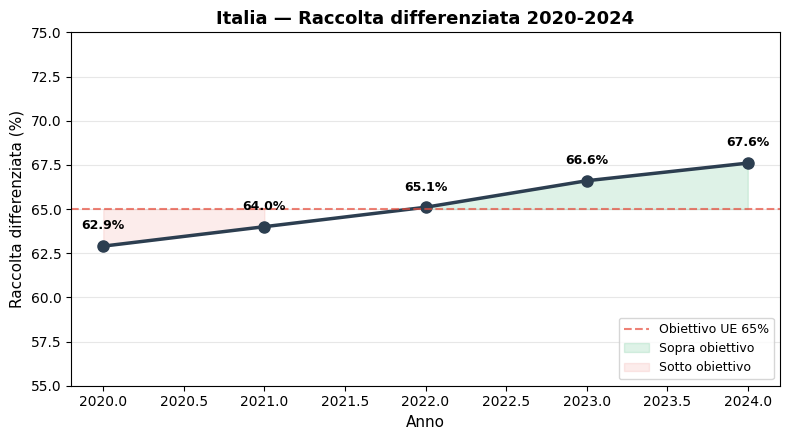

In [3]:
# Figura 1: Trend RD nazionale 2020-2024
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_copertura['anno'], df_copertura['rd_pct'], marker='o', linewidth=2.5, color='#2c3e50', markersize=8)
ax.axhline(y=65, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7, label='Obiettivo UE 65%')
ax.fill_between(df_copertura['anno'], 65, df_copertura['rd_pct'],
                where=(df_copertura['rd_pct'] >= 65), color='#27ae60', alpha=0.15, label='Sopra obiettivo')
ax.fill_between(df_copertura['anno'], 65, df_copertura['rd_pct'],
                where=(df_copertura['rd_pct'] < 65), color='#e74c3c', alpha=0.1, label='Sotto obiettivo')
ax.set_ylim(55, 75)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('Italia — Raccolta differenziata 2020-2024', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)
for _, r in df_copertura.iterrows():
    ax.annotate(f"{r['rd_pct']}%", (r['anno'], r['rd_pct']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_trend_rd_nazionale.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Raccolta differenziata per regione (2024)

In [4]:
df_regioni = con.execute(f"""
    SELECT regione,
           COUNT(DISTINCT codice_comune_istat) as comuni,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_pct,
           ROUND(SUM(totale_ru_tonnellate) / NULLIF(SUM(popolazione), 0) * 1000, 0) as kg_procapite
    FROM '{BASE}' WHERE anno = 2024 AND popolazione > 0
    GROUP BY regione ORDER BY rd_pct DESC
""").df()
display(df_regioni)

,regione,comuni,rd_pct,kg_procapite
0,Emilia-Romagna,329,78.8,667.0
1,Valle dAosta,1,78.6,500.0
2,Veneto,544,78.1,525.0
3,Sardegna,377,76.6,467.0
4,Trentino-Alto Adige,276,75.7,498.0
5,Lombardia,1473,74.4,484.0
6,Friuli-Venezia Giulia,215,72.7,536.0
7,Marche,225,71.8,516.0
8,Umbria,92,69.6,539.0
9,Piemonte,1152,68.9,522.0


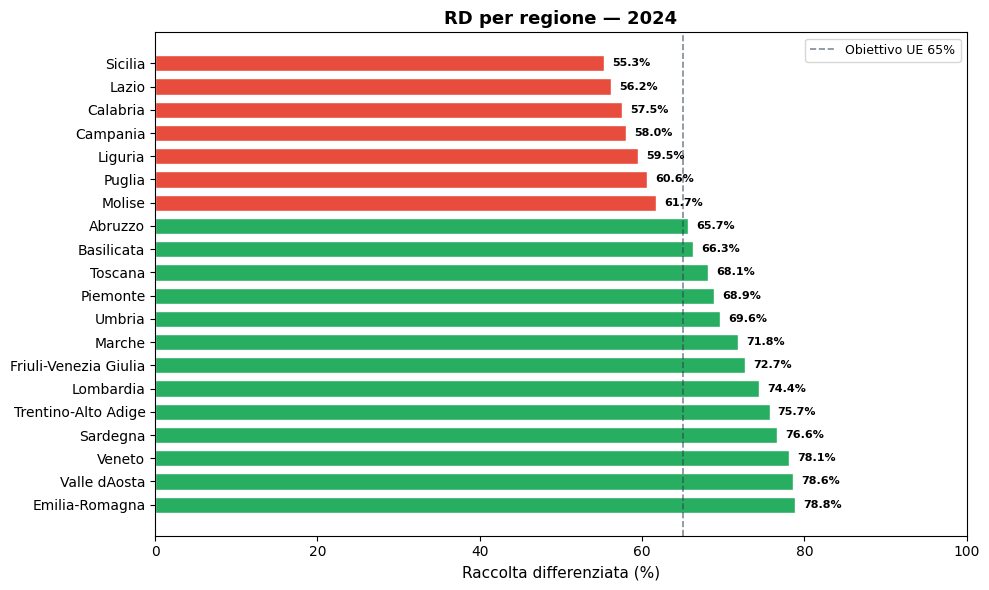

In [5]:
# Figura 2: RD per regione
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v >= 65 else '#e74c3c' for v in df_regioni['rd_pct']]
bars = ax.barh(df_regioni['regione'], df_regioni['rd_pct'], color=colors, edgecolor='white', height=0.7)
ax.axvline(x=65, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.6, label='Obiettivo UE 65%')
ax.set_xlabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('RD per regione — 2024', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)
for bar, val in zip(bars, df_regioni['rd_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}%',
            va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_rd_per_regione.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cross-dataset: produzione per km²

In [6]:
# Join ispra_ru_base x istat_elenco_comuni
df_province = con.execute(f"""
    SELECT r.regione, r.provincia,
           COUNT(DISTINCT r.codice_comune_istat) as comuni,
           ROUND(SUM(r.totale_ru_tonnellate) / NULLIF(SUM(s.superficie_km2), 0), 0) as ru_km2,
           ROUND(AVG(r.percentuale_rd), 1) as rd_media
    FROM '{BASE}' r
    INNER JOIN '{SUP}' s ON SUBSTR(r.codice_comune_istat, 3, 6) = s.codice_istat
    WHERE r.anno = 2024 AND r.popolazione > 0 AND s.superficie_km2 > 0
    GROUP BY r.regione, r.provincia ORDER BY ru_km2 DESC LIMIT 15
""").df()
display(df_province)

,regione,provincia,comuni,ru_km2,rd_media
0,Campania,Napoli,91,1256.0,62.9
1,Lombardia,Milano,133,963.0,77.2
2,Lombardia,Monza e della Brianza,54,930.0,82.2
3,Valle dAosta,Aosta,1,775.0,78.6
4,Friuli-Venezia Giulia,Trieste,6,551.0,64.0
5,Lazio,Roma,110,437.0,65.8
6,Toscana,Prato,7,423.0,71.1
7,Lombardia,Varese,133,344.0,81.3
8,Emilia-Romagna,Rimini,27,270.0,60.2
9,Veneto,Padova,100,240.0,79.7


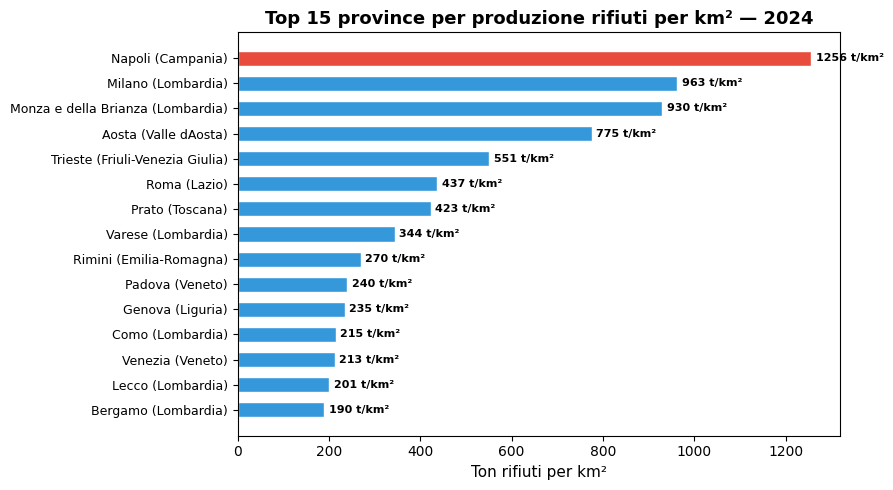

In [7]:
# Figura 3: Top province per ton/km²
fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"{r['provincia']} ({r['regione']})" for _, r in df_province.iterrows()]
colors_prov = ['#e74c3c' if 'Napoli' in r['provincia'] else '#3498db' for _, r in df_province.iterrows()]
bars = ax.barh(range(len(df_province)), df_province['ru_km2'][::-1], color=colors_prov[::-1], edgecolor='white', height=0.6)
ax.set_yticks(range(len(df_province)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel('Ton rifiuti per km²', fontsize=11)
ax.set_title('Top 15 province per produzione rifiuti per km² — 2024', fontsize=13, fontweight='bold')
for bar, val in zip(bars, df_province['ru_km2'][::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{int(val)} t/km²',
            va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_top_province.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Top comuni per ton/km²
df_comuni = con.execute(f"""
    SELECT r.comune, r.provincia, r.regione, r.popolazione,
           ROUND(s.superficie_km2, 2) as km2,
           ROUND(r.totale_ru_tonnellate / NULLIF(s.superficie_km2, 0), 0) as ru_km2,
           r.percentuale_rd
    FROM '{BASE}' r
    INNER JOIN '{SUP}' s ON SUBSTR(r.codice_comune_istat, 3, 6) = s.codice_istat
    WHERE r.anno = 2024 AND r.popolazione > 0 AND s.superficie_km2 > 1
    ORDER BY ru_km2 DESC LIMIT 20
""").df()
display(df_comuni)

,comune,provincia,regione,popolazione,km2,ru_km2,percentuale_rd
0,CASAVATORE,Napoli,Campania,18160,1.61,5065.0,45.10
1,PORTICI,Napoli,Campania,51351,4.64,5004.0,58.68
2,NAPOLI,Napoli,Campania,908082,119.24,4302.0,44.38
3,MELITO DI NAPOLI,Napoli,Campania,36143,3.78,4025.0,29.40
4,SAN GIORGIO A CREMANO,Napoli,Campania,41748,4.07,3659.0,58.43
5,MILANO,Milano,Lombardia,1366155,181.76,3618.0,63.33
6,TORINO,Torino,Piemonte,856745,130.00,3327.0,57.35
7,FRATTAMINORE,Napoli,Campania,15297,2.04,3039.0,51.26
8,AVERSA,Caserta,Campania,49295,8.85,3025.0,52.47
9,SANTANTIMO,Napoli,Campania,32428,5.91,2983.0,53.91


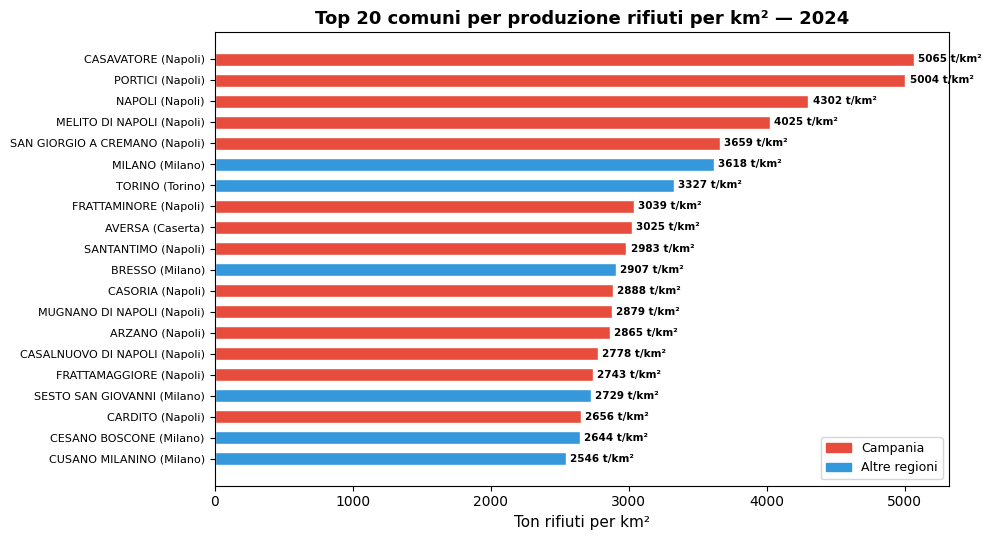

In [9]:
# Figura 4: Top comuni per ton/km²
fig, ax = plt.subplots(figsize=(10, 5.5))
y_labels = [f"{r['comune']} ({r['provincia']})" for _, r in df_comuni.iterrows()]
colors_com = ['#e74c3c' if r['regione'] == 'Campania' else '#3498db' for _, r in df_comuni.iterrows()]
bars = ax.barh(range(len(df_comuni)), df_comuni['ru_km2'][::-1], color=colors_com[::-1], edgecolor='white', height=0.6)
ax.set_yticks(range(len(df_comuni)))
ax.set_yticklabels(y_labels[::-1], fontsize=8)
ax.set_xlabel('Ton rifiuti per km²', fontsize=11)
ax.set_title('Top 20 comuni per produzione rifiuti per km² — 2024', fontsize=13, fontweight='bold')
ax.legend([plt.Rectangle((0,0),1,1,color='#e74c3c'), plt.Rectangle((0,0),1,1,color='#3498db')],
          ['Campania', 'Altre regioni'], fontsize=9, loc='lower right')
for bar, val in zip(bars, df_comuni['ru_km2'][::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{int(val)} t/km²',
            va='center', fontsize=7.5, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_top_comuni.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Divario Nord-Centro vs Sud-Isole

In [10]:
df_macro = con.execute(f"""
    SELECT r.anno,
           CASE WHEN r.regione IN ('Valle dAosta','Piemonte','Lombardia','Trentino-Alto Adige',
                                    'Veneto','Friuli-Venezia Giulia','Liguria','Emilia-Romagna',
                                    'Toscana','Umbria','Marche') THEN 'Nord-Centro'
                ELSE 'Sud e Isole' END as macroarea,
           ROUND(SUM(r.totale_rd_tonnellate) / NULLIF(SUM(r.totale_ru_tonnellate), 0) * 100, 1) as rd_pct,
           ROUND(SUM(r.totale_ru_tonnellate) / NULLIF(SUM(r.popolazione), 0) * 1000, 0) as kg_procapite,
           COUNT(DISTINCT r.codice_comune_istat) as comuni
    FROM '{BASE}' r WHERE r.popolazione > 0
    GROUP BY r.anno, macroarea ORDER BY macroarea, r.anno
""").df()
display(df_macro)

,anno,macroarea,rd_pct,kg_procapite,comuni
0,2020,Nord-Centro,69.6,515.0,4806
1,2021,Nord-Centro,70.0,526.0,4811
2,2022,Nord-Centro,70.9,516.0,4814
3,2023,Nord-Centro,72.3,523.0,4812
4,2024,Nord-Centro,73.2,539.0,4810
5,2020,Sud e Isole,53.2,455.0,2822
6,2021,Sud e Isole,55.2,471.0,2807
7,2022,Sud e Isole,56.7,466.0,2817
8,2023,Sud e Isole,58.0,461.0,2857
9,2024,Sud e Isole,59.1,467.0,2861


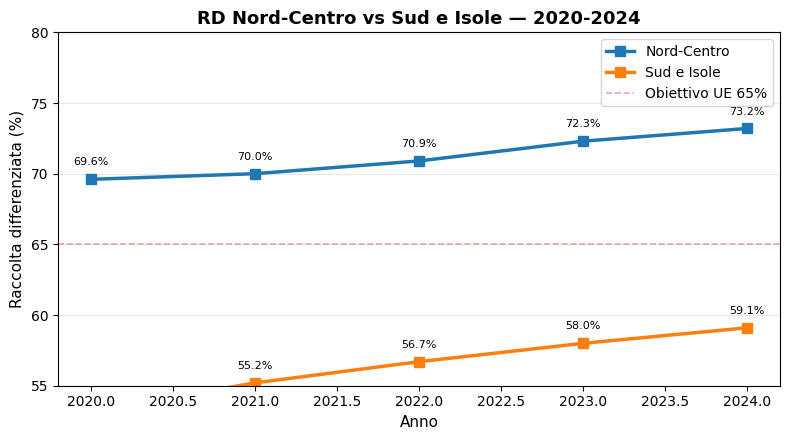

In [11]:
# Figura 5: RD Nord-Centro vs Sud-Isole
fig, ax = plt.subplots(figsize=(8, 4.5))
for area in ['Nord-Centro', 'Sud e Isole']:
    d = df_macro[df_macro['macroarea'] == area]
    ax.plot(d['anno'], d['rd_pct'], marker='s', linewidth=2.5, markersize=7, label=area)
ax.axhline(y=65, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.5, label='Obiettivo UE 65%')
ax.set_ylim(55, 80)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('RD Nord-Centro vs Sud e Isole — 2020-2024', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for _, r in df_macro.iterrows():
    ax.annotate(f"{r['rd_pct']}%", (r['anno'], r['rd_pct']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_macroarea_rd.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. RD % vs produzione pro-capite

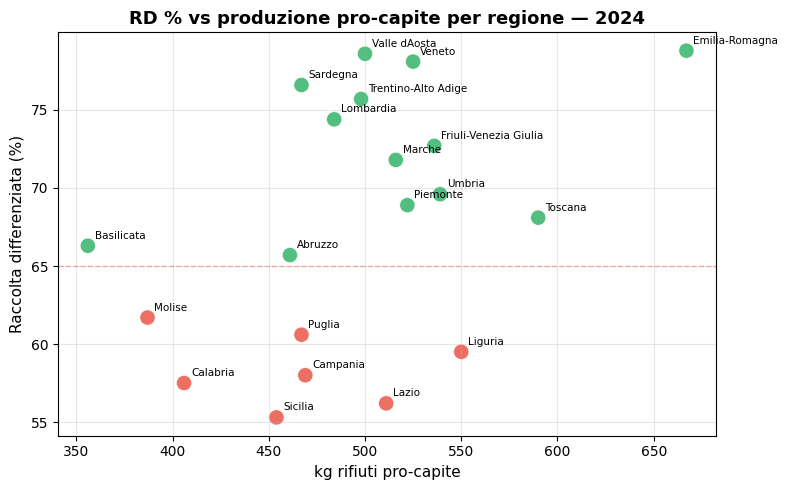

In [12]:
# Figura 6: RD % vs kg pro-capite per regione
fig, ax = plt.subplots(figsize=(8, 5))
colors_scatter = ['#27ae60' if v >= 65 else '#e74c3c' for v in df_regioni['rd_pct']]
ax.scatter(df_regioni['kg_procapite'], df_regioni['rd_pct'], c=colors_scatter, s=120, alpha=0.8, edgecolors='white', linewidth=0.5)
for _, r in df_regioni.iterrows():
    ax.annotate(r['regione'], (r['kg_procapite'], r['rd_pct']),
                textcoords="offset points", xytext=(5, 5), fontsize=7.5)
ax.axhline(y=65, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xlabel('kg rifiuti pro-capite', fontsize=11)
ax.set_ylabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('RD % vs produzione pro-capite per regione — 2024', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_rd_vs_procapite.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Regioni con la crescita più rapida

In [13]:
df_2020 = con.execute(f"""
    SELECT regione,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_2020
    FROM '{BASE}' WHERE anno = 2020 AND popolazione > 0
    GROUP BY regione
""").df()
df_2024 = con.execute(f"""
    SELECT regione,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_2024
    FROM '{BASE}' WHERE anno = 2024 AND popolazione > 0
    GROUP BY regione
""").df()
df_crescita = df_2020.merge(df_2024, on='regione')
df_crescita['delta'] = (df_crescita['rd_2024'] - df_crescita['rd_2020']).round(1)
df_crescita = df_crescita.sort_values('delta', ascending=False)
display(df_crescita)

,regione,rd_2020,rd_2024,delta
9,Sicilia,42.1,55.3,13.2
13,Valle dAosta,66.0,78.6,12.6
15,Basilicata,55.0,66.3,11.3
16,Emilia-Romagna,72.0,78.8,6.8
8,Puglia,54.3,60.6,6.3
17,Liguria,53.3,59.5,6.2
7,Molise,55.5,61.7,6.2
3,Toscana,62.2,68.1,5.9
5,Calabria,51.6,57.5,5.9
0,Friuli-Venezia Giulia,68.0,72.7,4.7


---
Notebook generato con dati pubblici da GCS (`gs://dataciviclab-clean/`).
Le figure in `figures/` sono referenziate dal README.